**Week 2 Assignment**

Subjects: Math  Art  English  Art  Art  English  Math  Math  Math  English

Score: 48  88  76  76  78  89  79  90  77  67  

Age: 17  16  16  15  16  18  16  17  16  16



1. State the chart types you would use to visualize for the following questions
- Age distribution
- Percentage of students taking each subject
- Average score for each subject
2. What is the Confidence interval for Age of the students?
3. Calculate the standard error for the Scores.

In [1]:
#import libraries for data manipulation, visualisations and statistics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [2]:
#define dataset
df = pd.DataFrame({
    'Subjects': ['Math', 'Art', 'English', 'Art', 'Art', 'English', 'Math', 'Math', 'Math', 'English'],
    'Score': [48, 88, 76, 76, 78, 89, 79, 90, 77, 67],
    'Age': [17, 16, 16, 15, 16, 18, 16, 17, 16, 16]
})
print(df)

  Subjects  Score  Age
0     Math     48   17
1      Art     88   16
2  English     76   16
3      Art     76   15
4      Art     78   16
5  English     89   18
6     Math     79   16
7     Math     90   17
8     Math     77   16
9  English     67   16


In [3]:
df.dtypes

Subjects    object
Score        int64
Age          int64
dtype: object

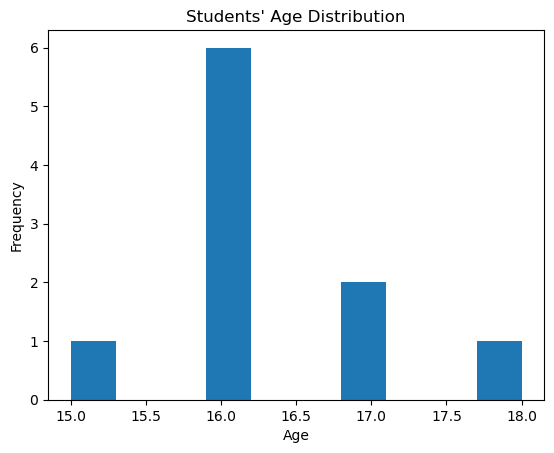

In [4]:
#Generate age distribution
df['Age'].plot(kind = 'hist')
plt.title("Students' Age Distribution")
plt.xlabel('Age')
plt.show();

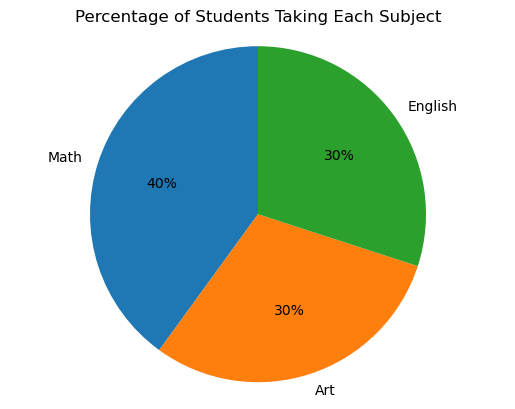

In [5]:
# Display percentage of students taking each subject
subject_counts = df['Subjects'].value_counts()
subject_counts.plot(kind='pie', autopct='%1.0f%%', startangle=90, legend=False)
plt.title('Percentage of Students Taking Each Subject')
plt.ylabel('')
plt.axis('equal')
plt.show();

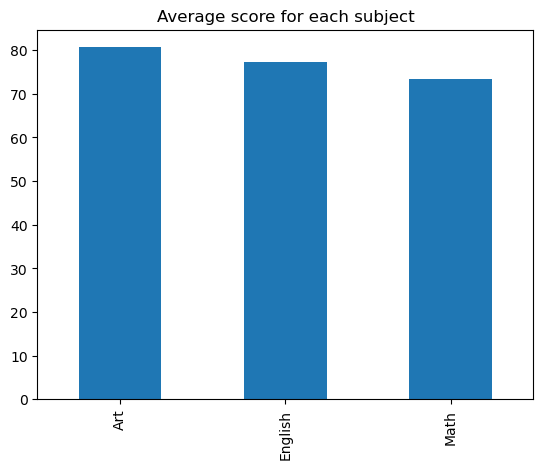

In [6]:
#Display average score for each subject
sub_avgscore = df.groupby('Subjects')['Score'].mean()
sub_avgscore.plot(kind = 'bar');
plt.xlabel("")
plt.title("Average score for each subject")
plt.show();

#### Find the confidence interval for Age of the students
The four steps for constructing a confidence interval:

1.   Identify a sample statistic
2.   Choose a confidence level
3.   Find the margin of error 
4.   Calculate the interval

To conduct confidence level for a sample size of less than 30, we use `scipy.stats.t.interval()` but incase of dataset larger than 30, we use `scipy.stats.norm.interval()`



In [7]:
# 1. Sample mean (loc)
age_mean = df['Age'].mean()

# 2. Define confidence level
confidence_level = 0.95

# 3. Degrees of freedom for t-distribution (n - 1) - this is needed for sample data less than 30
dof = len(df['Age']) - 1

# 4. Standard error of the mean (scale)
# Note: stats.sem defaults to ddof=1, providing the proper sample error adjustment
age_sem = stats.sem(df['Age'])

# Calculate the confidence interval using the t-distribution
age_ci = stats.t.interval(confidence_level, df=dof, loc=age_mean, scale=age_sem)

print(f"Age mean: {age_mean}")
print(f"\nStandard error of age: {age_sem}")
print("\nConfidence Interval for age of student (95% CI):")
print(age_ci)

Age mean: 16.3

Standard error of age: 0.2603416558635551

Confidence Interval for age of student (95% CI):
(np.float64(15.711066258398963), np.float64(16.88893374160104))


The confidence interval (CI) for Age of students at 95% confidence level = 15.71 - 16.89. This means we are 95% confident that the CI (15.71, 16.89) contains the true mean.

#### Find the standard error for the scores

In [8]:
scores_se = stats.sem(df['Score'])
print(f"Standard error of scores: {scores_se}")

Standard error of scores: 3.9180494013106966


In [11]:
#confirming the standard errors of score using manual formula
scores_seV2 = df['Score'].std() / np.sqrt(df.shape[0])
print(f'Standard deviation of scores: {df['Score'].std()}')
print(f"Standard error of scores: {scores_seV2}")

Standard deviation of scores: 12.38996009320091
Standard error of scores: 3.9180494013106966


Assignment done by Aishat Omolabake Ajibola